<a href="https://colab.research.google.com/github/Keaton-Francis-Fernandes/Battery-SOC/blob/main/battery_soc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Performing EDA on the dataset

Importing the required libraries

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [7]:
import pandas as pd

file_path = "Battery_soc.csv"
battery_data = pd.read_csv(file_path)

print(battery_data.head())

   Source(Lat)  source(Long)  Destination(Lat)  Destination(Long)  Speed(km)  \
0      12.9830       80.2594          147.5358           214.8122         70   
1      13.0827       80.2707          147.4587           214.6467         68   
2      13.0827       80.2707          147.4587           214.6467         75   
3      13.0827       80.2707          147.4587           214.6467         60   
4      11.9401       79.4861           12.9165            79.1325         58   

   Distance(km)  Altimetry1  Altimetry2  Altimetry3  Altimetry4  Altimetry5  \
0         137.0      5.9826      4.0188     8.96590      3.4065    14.25980   
1         381.0      4.3615      6.9664     5.53170      3.6215     5.87051   
2         766.0      4.3615     11.2439    27.49690     22.0944    63.81500   
3         706.0      4.3615     11.2594    39.00680     56.5993    20.42650   
4         128.0     46.1555     69.8356    86.71276    222.6724   134.86660   

   Altimetry6  Altimetry7  Altimetry8  Altim

In [8]:
print("Dataset Info:")
print(battery_data.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Source(Lat)        1000 non-null   float64
 1   source(Long)       1000 non-null   float64
 2   Destination(Lat)   1000 non-null   float64
 3   Destination(Long)  1000 non-null   float64
 4   Speed(km)          1000 non-null   int64  
 5   Distance(km)       1000 non-null   float64
 6   Altimetry1         1000 non-null   float64
 7   Altimetry2         1000 non-null   float64
 8   Altimetry3         1000 non-null   float64
 9   Altimetry4         1000 non-null   float64
 10  Altimetry5         1000 non-null   float64
 11  Altimetry6         1000 non-null   float64
 12  Altimetry7         1000 non-null   float64
 13  Altimetry8         1000 non-null   float64
 14  Altimetry9         1000 non-null   float64
 15  Altimetry10        1000 non-null   float64
 16  Time(minnut

In [9]:
print("\nFirst 5 Rows of the Dataset:")
print(battery_data.head())


First 5 Rows of the Dataset:
   Source(Lat)  source(Long)  Destination(Lat)  Destination(Long)  Speed(km)  \
0      12.9830       80.2594          147.5358           214.8122         70   
1      13.0827       80.2707          147.4587           214.6467         68   
2      13.0827       80.2707          147.4587           214.6467         75   
3      13.0827       80.2707          147.4587           214.6467         60   
4      11.9401       79.4861           12.9165            79.1325         58   

   Distance(km)  Altimetry1  Altimetry2  Altimetry3  Altimetry4  Altimetry5  \
0         137.0      5.9826      4.0188     8.96590      3.4065    14.25980   
1         381.0      4.3615      6.9664     5.53170      3.6215     5.87051   
2         766.0      4.3615     11.2439    27.49690     22.0944    63.81500   
3         706.0      4.3615     11.2594    39.00680     56.5993    20.42650   
4         128.0     46.1555     69.8356    86.71276    222.6724   134.86660   

   Altimetry6 

In [10]:
print("\nSummary Statistics:")
print(battery_data.describe())


Summary Statistics:
       Source(Lat)  source(Long)  Destination(Lat)  Destination(Long)  \
count  1000.000000   1000.000000       1000.000000        1000.000000   
mean     12.373991     79.681539         22.493957          89.574023   
std       0.874856      0.978916         36.930423          37.793216   
min      10.767200     76.733700          8.088300          66.955800   
25%      11.940100     79.694700         10.362400          77.473500   
50%      12.983000     80.259400         11.016800          78.119800   
75%      13.082700     80.270700         13.082700          79.843700   
max      13.082700     80.270700        147.535800         230.646700   

         Speed(km)  Distance(km)   Altimetry1   Altimetry2   Altimetry3  \
count  1000.000000   1000.000000  1000.000000  1000.000000  1000.000000   
mean     59.290000    330.426000   164.716643   145.402020    82.598162   
std      10.922692    232.090641   486.824852   377.057563   124.987286   
min      30.000000   

In [11]:
print("\nMissing Values:")
print(battery_data.isnull().sum())


Missing Values:
Source(Lat)          0
source(Long)         0
Destination(Lat)     0
Destination(Long)    0
Speed(km)            0
Distance(km)         0
Altimetry1           0
Altimetry2           0
Altimetry3           0
Altimetry4           0
Altimetry5           0
Altimetry6           0
Altimetry7           0
Altimetry8           0
Altimetry9           0
Altimetry10          0
Time(minnutes)       0
Soc                  0
dtype: int64


In [12]:
correlation_matrix = battery_data.corr()
correlation_matrix

,Source(Lat),source(Long),Destination(Lat),Destination(Long),Speed(km),Distance(km),Altimetry1,Altimetry2,Altimetry3,Altimetry4,Altimetry5,Altimetry6,Altimetry7,Altimetry8,Altimetry9,Altimetry10,Time(minnutes),Soc
Source(Lat),1.000000,0.613546,0.247770,0.243979,0.051191,0.440506,-0.319750,-0.320655,-0.366265,-0.381697,-0.326009,-0.394512,-0.208733,-0.473983,-0.267051,-0.280047,0.390898,0.297266
source(Long),0.613546,1.000000,0.192451,0.182589,0.057988,0.315743,-0.909138,-0.911116,-0.919076,-0.810186,-0.636694,-0.663603,-0.422738,-0.742654,-0.784807,-0.172242,0.288681,0.270613
Destination(Lat),0.247770,0.192451,1.000000,0.994698,0.148834,0.176346,-0.109669,-0.120603,-0.163688,-0.216351,-0.221239,-0.226030,-0.212986,-0.098524,-0.128378,-0.018458,0.172838,0.161221
Destination(Long),0.243979,0.182589,0.994698,1.000000,0.120618,0.152389,-0.103797,-0.114425,-0.157302,-0.211521,-0.225588,-0.229224,-0.206207,-0.119863,-0.138364,-0.053779,0.145109,0.135656
Speed(km),0.051191,0.057988,0.148834,0.120618,1.000000,0.196538,0.073614,0.087922,0.102934,0.106124,0.240477,0.265130,0.429893,0.286507,0.276044,0.452228,0.303296,0.360734
Distance(km),0.440506,0.315743,0.176346,0.152389,0.196538,1.000000,-0.097426,-0.093387,-0.067515,-0.079573,0.073423,0.084112,0.029876,0.155774,0.136516,0.303696,0.959806,0.794181
Altimetry1,-0.319750,-0.909138,-0.109669,-0.103797,0.073614,-0.097426,1.000000,0.998744,0.954669,0.773270,0.605505,0.621863,0.459561,0.684549,0.900369,0.198629,-0.046116,-0.032537
Altimetry2,-0.320655,-0.911116,-0.120603,-0.114425,0.087922,-0.093387,0.998744,1.000000,0.966519,0.798640,0.638054,0.654420,0.493924,0.696352,0.912837,0.204929,-0.041745,-0.032166
Altimetry3,-0.366265,-0.919076,-0.163688,-0.157302,0.102934,-0.067515,0.954669,0.966519,1.000000,0.914433,0.790694,0.806941,0.574066,0.766632,0.932906,0.211444,-0.031905,-0.065439
Altimetry4,-0.381697,-0.810186,-0.216351,-0.211521,0.106124,-0.079573,0.773270,0.798640,0.914433,1.000000,0.901923,0.907569,0.575032,0.698134,0.862179,0.161755,-0.070264,-0.141159


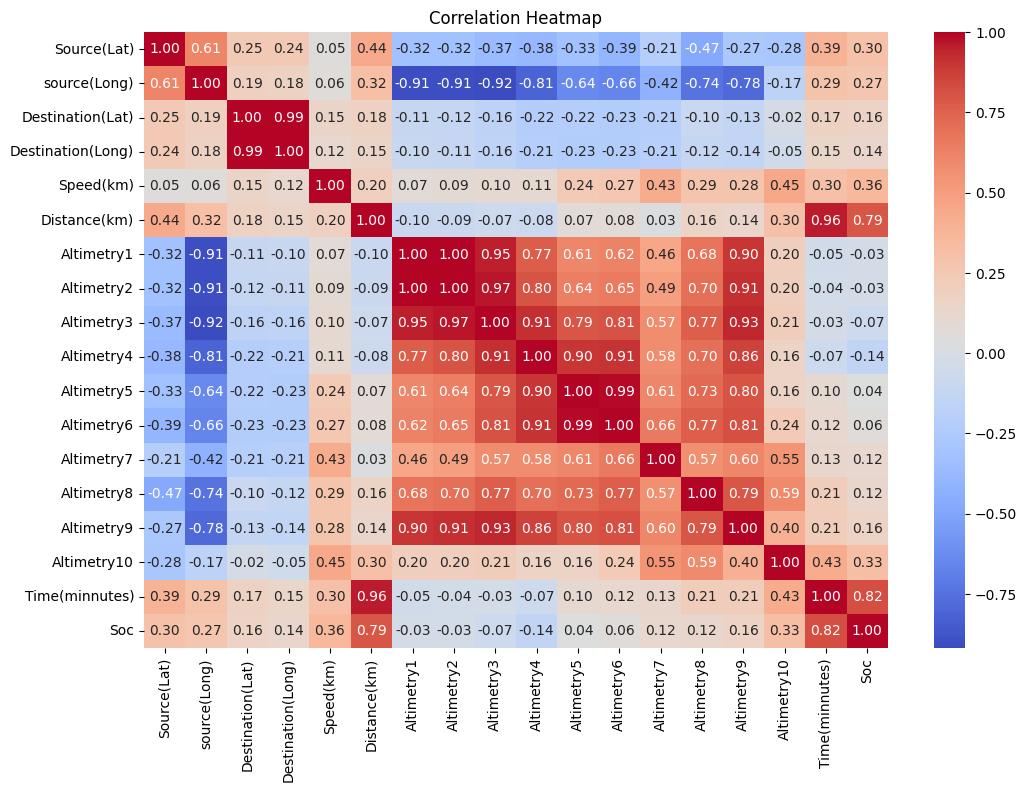

In [13]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In the above correlation matrix , it is observed that our target SOC has good correlation with Time and distance


Text(0, 0.5, 'State of Charge (SOC)')

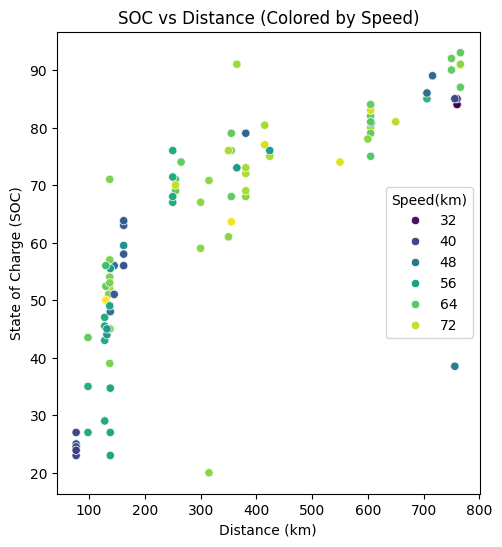

In [14]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(data=battery_data, x="Distance(km)", y="Soc", hue="Speed(km)", palette="viridis")
plt.title("SOC vs Distance (Colored by Speed)")
plt.xlabel("Distance (km)")
plt.ylabel("State of Charge (SOC)")

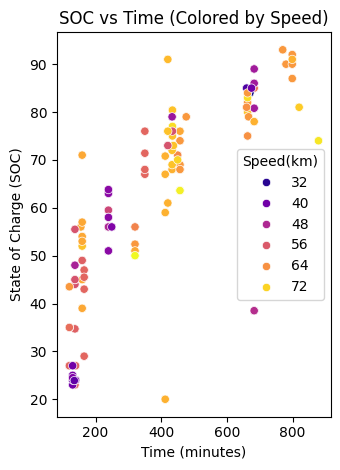

In [15]:
plt.subplot(1, 2, 2)
sns.scatterplot(data=battery_data, x="Time(minnutes)", y="Soc", hue="Speed(km)", palette="plasma")
plt.title("SOC vs Time (Colored by Speed)")
plt.xlabel("Time (minutes)")
plt.ylabel("State of Charge (SOC)")
plt.tight_layout()
plt.show()

In [27]:
features = [
    "Speed(km)", "Distance(km)", "Altimetry1", "Altimetry2", "Altimetry3",
    "Altimetry4", "Altimetry5", "Altimetry6", "Altimetry7", "Altimetry8",
    "Altimetry9", "Altimetry10", "Time(minnutes)"
]
target = "Soc"

X = battery_data[features]
y = battery_data[target]

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [18]:
model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [40]:
y_val_pred = model.predict(X_val_scaled)
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = mean_squared_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)

print("\nValidation Set Evaluation:")
print(f"Mean Absolute Error (MAE): {val_mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {val_rmse:.2f}")
print(f"R² Score: {val_r2:.2f}")


Validation Set Evaluation:
Mean Absolute Error (MAE): 3.81
Root Mean Squared Error (RMSE): 42.67
R² Score: 0.90


In [35]:
y_test_pred = model.predict(X_test_scaled)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nTest Set Evaluation:")
print(f"Mean Absolute Error (MAE): {test_mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {test_rmse:.2f}")
print(f"R² Score: {test_r2:.2f}")


Test Set Evaluation:
Mean Absolute Error (MAE): 3.80
Root Mean Squared Error (RMSE): 46.70
R² Score: 0.89


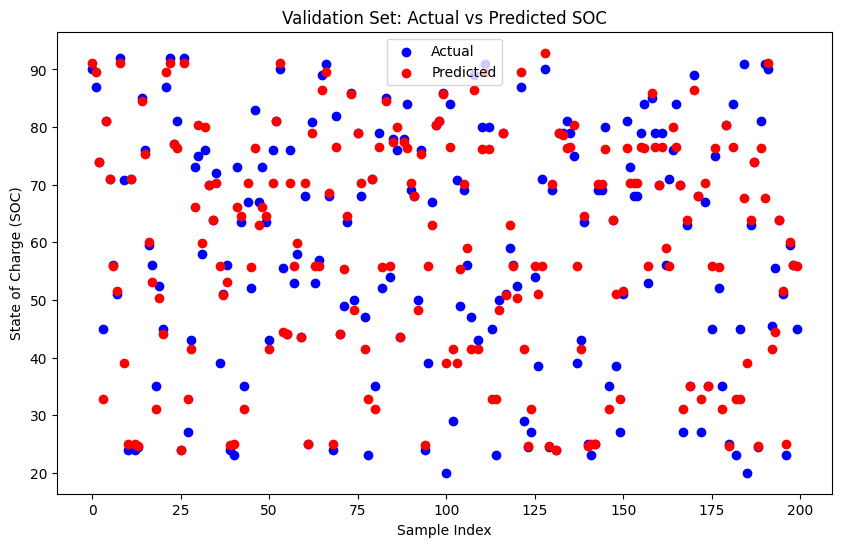

In [36]:
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_val)), y_val, color='blue', label='Actual')
plt.scatter(range(len(y_val_pred)), y_val_pred, color='red', label='Predicted')
plt.title('Validation Set: Actual vs Predicted SOC')
plt.xlabel('Sample Index')
plt.ylabel('State of Charge (SOC)')
plt.legend()
plt.show()

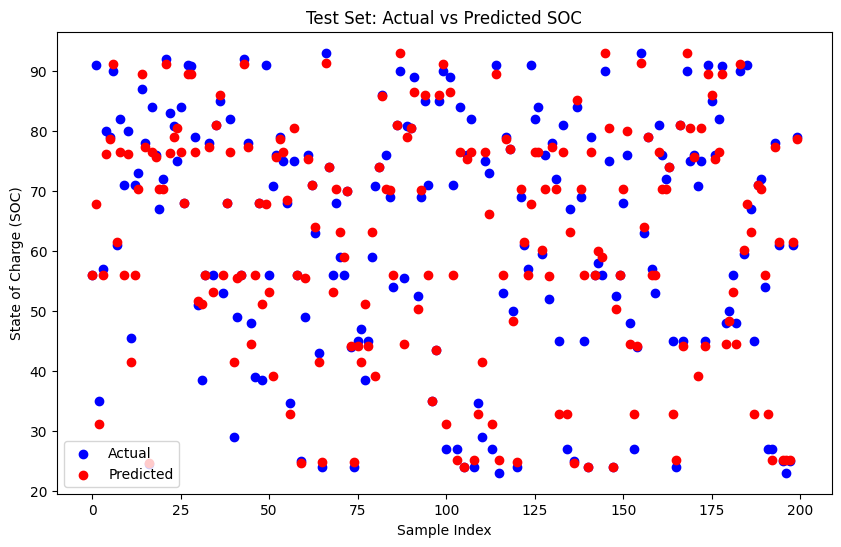

In [37]:
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual')
plt.scatter(range(len(y_test_pred)), y_test_pred, color='red', label='Predicted')
plt.title('Test Set: Actual vs Predicted SOC')
plt.xlabel('Sample Index')
plt.ylabel('State of Charge (SOC)')
plt.legend()
plt.show()

Implementing another AI model using Gradient Boosting regressor

In [39]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(random_state=42, n_estimators=150, learning_rate=0.1, max_depth=3)
gbr_model.fit(X_train_scaled, y_train)

GradientBoostingRegressor(n_estimators=150, random_state=42)

In [43]:
y_val_pred = gbr_model.predict(X_val_scaled)
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = mean_squared_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)

print("\nValidation Set Evaluation:")
print(f"Mean Absolute Error (MAE): {val_mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {val_rmse:.2f}")
print(f"R² Score: {val_r2:.2f}")


Validation Set Evaluation:
Mean Absolute Error (MAE): 2.83
Root Mean Squared Error (RMSE): 28.89
R² Score: 0.93


In [45]:
y_test_pred = gbr_model.predict(X_test_scaled)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nTest Set Evaluation:")
print(f"Mean Absolute Error (MAE): {test_mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {test_rmse:.2f}")
print(f"R² Score: {test_r2:.2f}")


Test Set Evaluation:
Mean Absolute Error (MAE): 2.70
Root Mean Squared Error (RMSE): 29.57
R² Score: 0.93


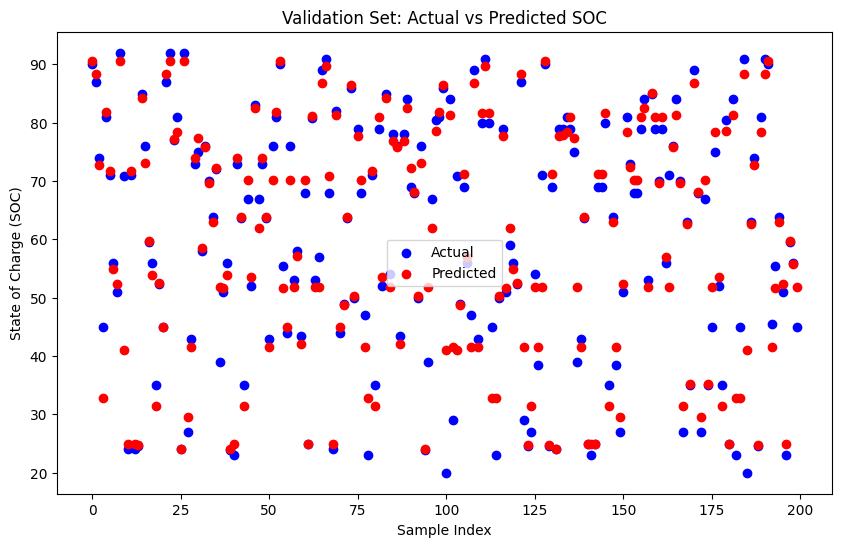

In [46]:
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_val)), y_val, color='blue', label='Actual')
plt.scatter(range(len(y_val_pred)), y_val_pred, color='red', label='Predicted')
plt.title('Validation Set: Actual vs Predicted SOC')
plt.xlabel('Sample Index')
plt.ylabel('State of Charge (SOC)')
plt.legend()
plt.show()

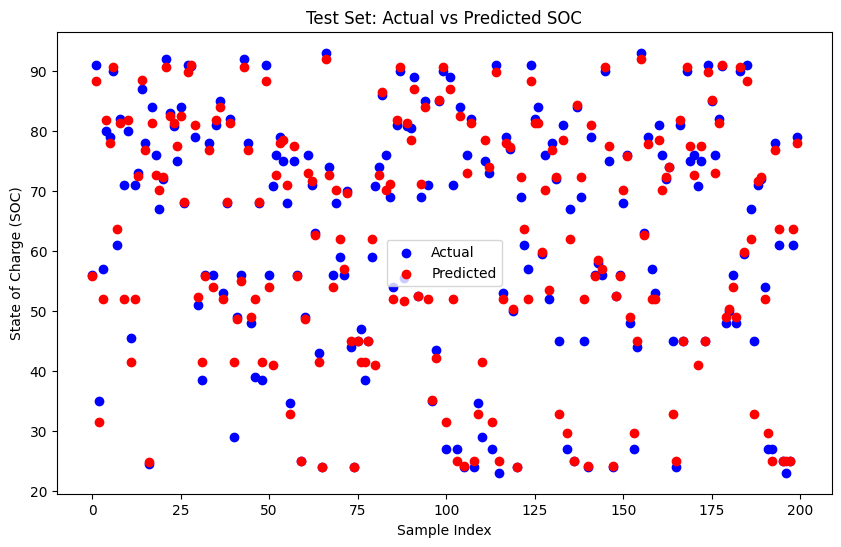

In [47]:
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual')
plt.scatter(range(len(y_test_pred)), y_test_pred, color='red', label='Predicted')
plt.title('Test Set: Actual vs Predicted SOC')
plt.xlabel('Sample Index')
plt.ylabel('State of Charge (SOC)')
plt.legend()
plt.show()